In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/train.csv")   
target = "SalePrice"

print("Shape:", df.shape)

# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
print("\nMissing values:")
print(missing[missing > 0])

# Skewness
print("\nSkewness:", df[target].skew())

# Top correlations
corr = df.select_dtypes(include=np.number).corr()[target].sort_values(ascending=False)
print("\nTop 10 correlations:")
print(corr.head(10))

Shape: (1460, 81)

Missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Skewness: 1.8828757597682129

Top 10 correlations:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


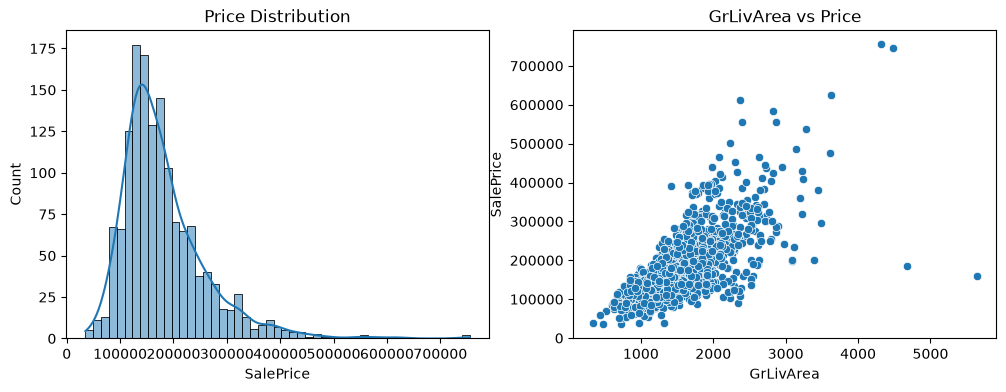

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[target], kde=True, ax=axes[0])
axes[0].set_title("Price Distribution")

sns.scatterplot(x=df["GrLivArea"], y=df[target], ax=axes[1])
axes[1].set_title("GrLivArea vs Price")

plt.show()

In [3]:
print(corr.head(11))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


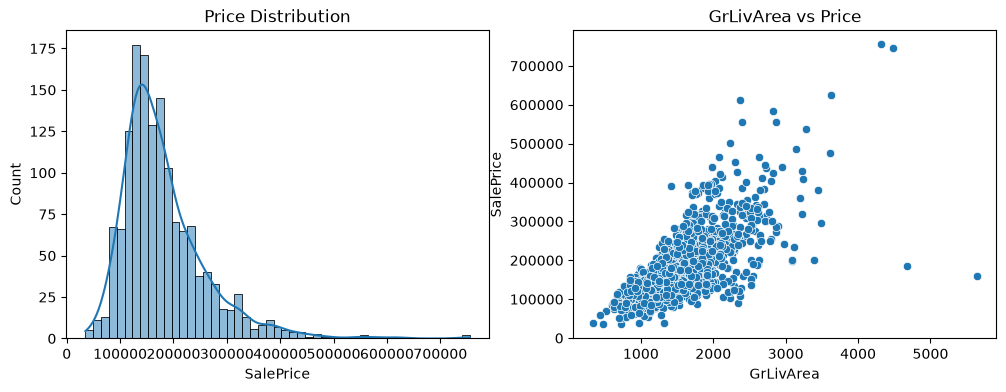

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[target], kde=True, ax=axes[0])
axes[0].set_title("Price Distribution")

sns.scatterplot(x=df["GrLivArea"], y=df[target], ax=axes[1])
axes[1].set_title("GrLivArea vs Price")

plt.show()

In [5]:
df = df[~((df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000))]